# 📊 Decision Tree vs 1D CNN vs Weighted Ensemble Evaluator

This Jupyter Notebook evaluates **Decision Tree** models, **1D CNN (TFLite)** models, and a **Configurable Weighted Ensemble** across labeled patient records in `process_labeled_data`.

> All results, tables, and confusion matrix heatmaps are displayed **directly inside this notebook** (no external file dependencies).

### ⚙️ How to Use:
1. Adjust `NUM_FILES` in Cell 2 to change how many patient CSV files to evaluate (or set to `-1` for ALL files).
2. Adjust `WEIGHT_DT` and `WEIGHT_CNN` to change model weighting.
3. Run all cells to view inline confusion matrices and performance tables.


In [1]:
import os
import glob
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tflite_runtime.interpreter as tflite

%matplotlib inline
print("All libraries imported successfully!")


All libraries imported successfully!


In [7]:
# USER CONFIGURATION PARAMETERS
NUM_FILES = 1500         # Number of CSV files to evaluate (e.g. 5, 10, 20, or -1 for ALL 197 files!)
WEIGHT_DT = 0.5        # Weight assigned to Decision Tree model
WEIGHT_CNN = 0.5       # Weight assigned to 1D CNN model
DECISION_THRESHOLD = 0.5
STRIDE = 5             # Window stride in seconds
WINDOW_SIZE = 600

DATA_DIR = "process_labeled_data"
DT_MODEL_DIR = "simple/models/decision_tree"
DT_SCALER_DIR = "models/scalers"
CNN_MODEL_DIR = "CNN"
CNN_SCALER_PATH = "CNN/scaler_1d_cnn.json"

TARGET_CONDITIONS = ["Future_Hypotension", "Future_Hypoxia", "Future_Tachycardia"]

tot_w = WEIGHT_DT + WEIGHT_CNN
W_DT = WEIGHT_DT / tot_w if tot_w > 0 else 0.5
W_CNN = WEIGHT_CNN / tot_w if tot_w > 0 else 0.5

print(f"Configured: NUM_FILES={NUM_FILES} | W_DT={W_DT:.2f} | W_CNN={W_CNN:.2f} | STRIDE={STRIDE}s")


Configured: NUM_FILES=1500 | W_DT=0.50 | W_CNN=0.50 | STRIDE=5s


In [8]:
CHANNELS = [
    "Solar8000/HR", "Solar8000/ART_SBP", "Solar8000/ART_DBP", "Solar8000/ART_MBP",
    "Solar8000/PLETH_SPO2", "Solar8000/RR_CO2", "Solar8000/ETCO2", "Primus/FIO2", "Solar8000/BT",
    "Feature_Pulse_Pressure", "Feature_Shock_Index", "Feature_Modified_Shock_Index",
    "Feature_Rate_Pressure_Product", "Feature_HR_Mean_60s", "Feature_HR_Std_60s",
    "Feature_HR_Delta_60s", "Feature_MBP_Mean_60s", "Feature_MBP_Std_60s", "Feature_MBP_Delta_60s"
]

def extract_95_features(raw_matrix):
    feats = []
    for c in range(raw_matrix.shape[1]):
        col = raw_matrix[:, c]
        feats.extend([col.mean(), col.std(ddof=0), col.min(), col.max(), (col[-1] - col[0]) / 600.00001])
    return np.array(feats, dtype=np.float32)

def calculate_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5
    except Exception:
        auc = 0.5
    return {"cm": cm, "tn": tn, "fp": fp, "fn": fn, "tp": tp, "acc": acc, "prec": prec, "rec": rec, "spec": spec, "f1": f1, "auc": auc}


In [9]:
with open(CNN_SCALER_PATH) as f:
    cnn_sc = json.load(f)
cnn_means = np.array(list(cnn_sc["mean"].values()), dtype=np.float32)
cnn_stds = np.array(list(cnn_sc["std"].values()), dtype=np.float32)

dt_models = {}
dt_scalers_mean = {}
dt_scalers_std = {}
cnn_interpreters = {}

for target in TARGET_CONDITIONS:
    dt_models[target] = joblib.load(os.path.join(DT_MODEL_DIR, f"dt_{target}.joblib"))
    with open(os.path.join(DT_SCALER_DIR, f"scaler_{target}.json")) as f:
        sc = json.load(f)
    dt_scalers_mean[target] = np.array(list(sc["mean"].values()), dtype=np.float32)
    dt_scalers_std[target] = np.array(list(sc["std"].values()), dtype=np.float32)
    
    interp = tflite.Interpreter(model_path=os.path.join(CNN_MODEL_DIR, f"cnn_{target}.tflite"))
    interp.allocate_tensors()
    cnn_interpreters[target] = interp

print("Loaded Decision Tree and CNN models for all 3 targets!")


Loaded Decision Tree and CNN models for all 3 targets!


In [10]:
all_csvs = sorted(glob.glob(os.path.join(DATA_DIR, "patient_*_1hz.csv")))
csv_files = all_csvs if NUM_FILES == -1 else all_csvs[:NUM_FILES]
print(f"Evaluating {len(csv_files)} CSV files...")

ground_truth = {t: [] for t in TARGET_CONDITIONS}
probs_dt = {t: [] for t in TARGET_CONDITIONS}
probs_cnn = {t: [] for t in TARGET_CONDITIONS}
probs_ens = {t: [] for t in TARGET_CONDITIONS}

for idx, csv_file in enumerate(csv_files, 1):
    df = pd.read_csv(csv_file)
    if not all(c in df.columns for c in CHANNELS):
        continue
    df_ch = df[CHANNELS].ffill().bfill().fillna(0)
    arr_data = df_ch.values.astype(np.float32)
    N = len(arr_data)
    if N < WINDOW_SIZE:
        continue
        
    for start_idx in range(0, N - WINDOW_SIZE + 1, STRIDE):
        end_idx = start_idx + WINDOW_SIZE
        window_raw = arr_data[start_idx:end_idx]
        window_cnn_scaled = ((window_raw - cnn_means) / cnn_stds).reshape(1, WINDOW_SIZE, 19).astype(np.float32)
        feats_95_raw = extract_95_features(window_raw)
        
        for target in TARGET_CONDITIONS:
            y_val = df[target].iloc[end_idx - 1] if target in df.columns else 0
            y_true_bin = 1 if y_val > 0.5 else 0
            
            dt_scaled = ((feats_95_raw - dt_scalers_mean[target]) / dt_scalers_std[target]).reshape(1, 95)
            p_dt = float(dt_models[target].predict_proba(dt_scaled)[0, 1])
            
            interp = cnn_interpreters[target]
            in_idx = interp.get_input_details()[0]["index"]
            out_idx = interp.get_output_details()[0]["index"]
            interp.set_tensor(in_idx, window_cnn_scaled)
            interp.invoke()
            p_cnn = float(interp.get_tensor(out_idx)[0][0])
            
            p_ens = W_DT * p_dt + W_CNN * p_cnn
            
            ground_truth[target].append(y_true_bin)
            probs_dt[target].append(p_dt)
            probs_cnn[target].append(p_cnn)
            probs_ens[target].append(p_ens)

print(f"Data Processing Complete! Evaluated {len(ground_truth['Future_Hypotension'])} total windows.")


Evaluating 1500 CSV files...
Data Processing Complete! Evaluated 3679753 total windows.


 CLINICAL TARGET: Future Hypotension
Model Architecture     | Accuracy | Precision | Recall | Specificity | F1-Score | ROC-AUC | TP   | FP   | TN   | FN  
----------------------------------------------------------------------------------------------------
1. Decision Tree       | 0.6538   | 0.3048    | 0.1731 | 0.8439      | 0.2208   | 0.5213  | 180535 | 411727 | 2225282 | 862209
2. 1D CNN TFLite       | 0.2834   | 0.2834    | 1.0000 | 0.0000      | 0.4416   | 0.7581  | 1042744 | 2637009 | 0    | 0   
3. Ensemble (0.50 DT + 0.50 CNN) | 0.6281   | 0.3241    | 0.2876 | 0.7628      | 0.3048   | 0.6722  | 299940 | 625615 | 2011394 | 742804
----------------------------------------------------------------------------------------------------


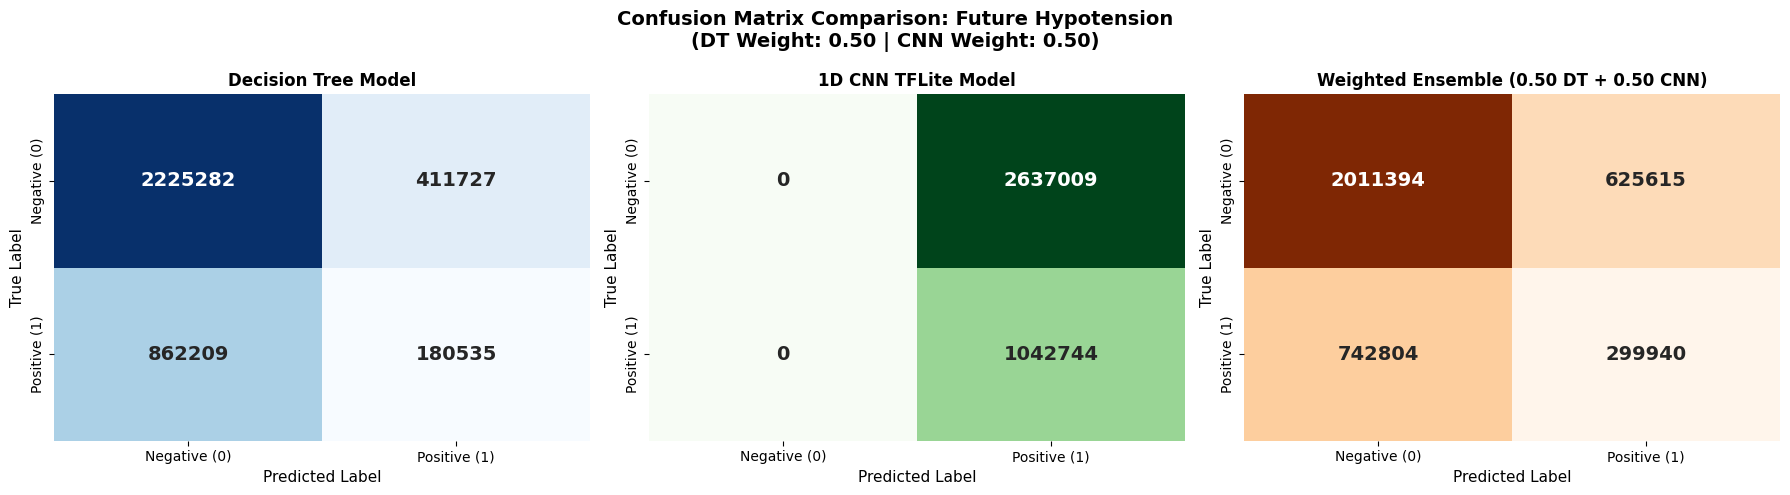

 CLINICAL TARGET: Future Hypoxia
Model Architecture     | Accuracy | Precision | Recall | Specificity | F1-Score | ROC-AUC | TP   | FP   | TN   | FN  
----------------------------------------------------------------------------------------------------
1. Decision Tree       | 0.8753   | 0.0476    | 0.0779 | 0.9175      | 0.0591   | 0.5356  | 14417 | 288215 | 3206544 | 170577
2. 1D CNN TFLite       | 0.0503   | 0.0503    | 1.0000 | 0.0000      | 0.0957   | 0.5000  | 184994 | 3494759 | 0    | 0   
3. Ensemble (0.50 DT + 0.50 CNN) | 0.0503   | 0.0503    | 1.0000 | 0.0000      | 0.0957   | 0.5356  | 184994 | 3494759 | 0    | 0   
----------------------------------------------------------------------------------------------------


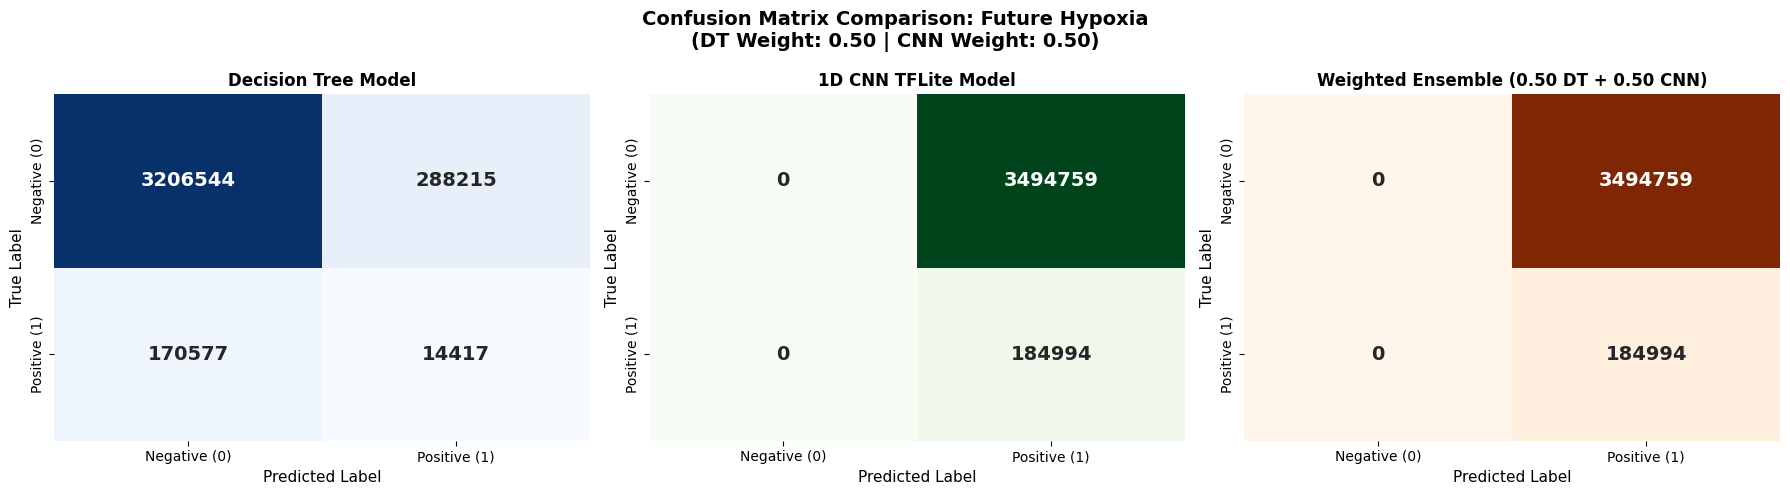

 CLINICAL TARGET: Future Tachycardia
Model Architecture     | Accuracy | Precision | Recall | Specificity | F1-Score | ROC-AUC | TP   | FP   | TN   | FN  
----------------------------------------------------------------------------------------------------
1. Decision Tree       | 0.8757   | 0.2057    | 0.1070 | 0.9566      | 0.1408   | 0.6382  | 37455 | 144627 | 3185046 | 312625
2. 1D CNN TFLite       | 0.1515   | 0.0961    | 0.9419 | 0.0684      | 0.1744   | 0.7063  | 329741 | 3101829 | 227844 | 20339
3. Ensemble (0.50 DT + 0.50 CNN) | 0.2117   | 0.0975    | 0.8827 | 0.1412      | 0.1756   | 0.6534  | 309030 | 2859678 | 469995 | 41050
----------------------------------------------------------------------------------------------------


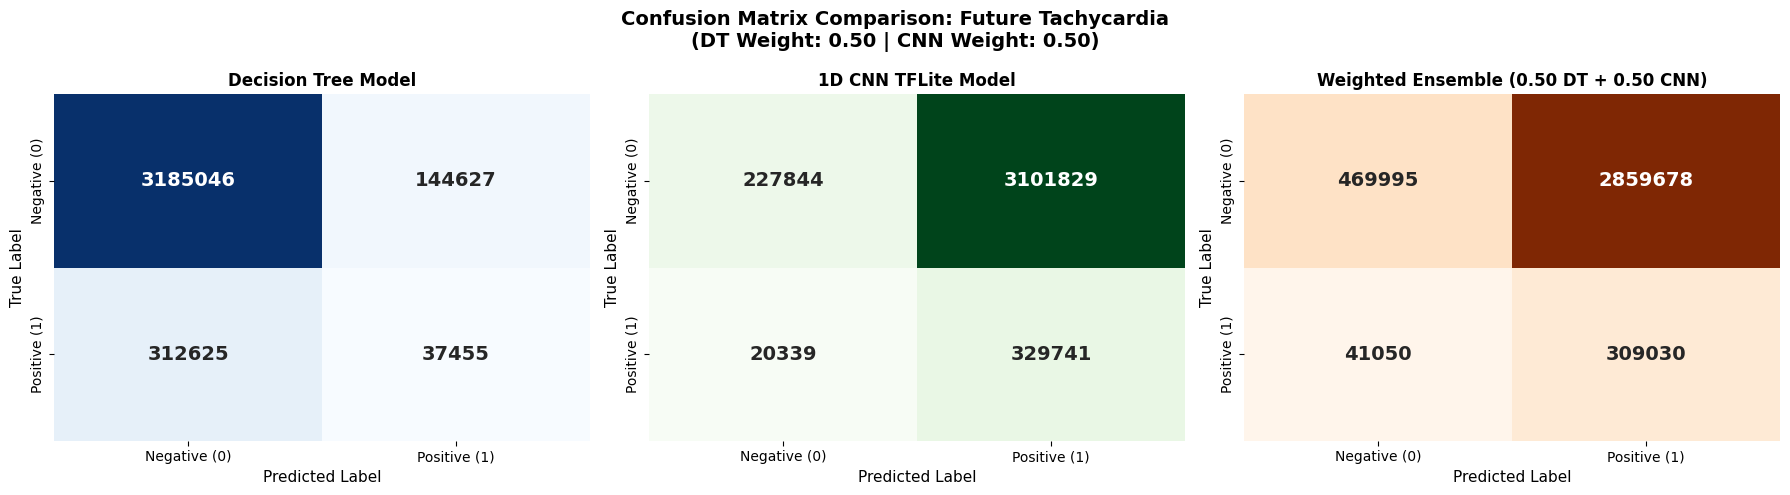

In [11]:
# Render Benchmark Tables and Side-by-Side Confusion Matrices inline in Notebook
for target in TARGET_CONDITIONS:
    y_true = np.array(ground_truth[target])
    p_dt_arr = np.array(probs_dt[target])
    p_cnn_arr = np.array(probs_cnn[target])
    p_ens_arr = np.array(probs_ens[target])
    
    y_pred_dt = (p_dt_arr >= DECISION_THRESHOLD).astype(int)
    y_pred_cnn = (p_cnn_arr >= DECISION_THRESHOLD).astype(int)
    y_pred_ens = (p_ens_arr >= DECISION_THRESHOLD).astype(int)
    
    m_dt = calculate_metrics(y_true, y_pred_dt, p_dt_arr)
    m_cnn = calculate_metrics(y_true, y_pred_cnn, p_cnn_arr)
    m_ens = calculate_metrics(y_true, y_pred_ens, p_ens_arr)
    
    target_title = target.replace("_", " ")
    print("=" * 100)
    print(f" CLINICAL TARGET: {target_title}")
    print("=" * 100)
    headers = ["Model Architecture", "Accuracy", "Precision", "Recall", "Specificity", "F1-Score", "ROC-AUC", "TP", "FP", "TN", "FN"]
    fmt_str = "{:<22} | {:<8} | {:<9} | {:<6} | {:<11} | {:<8} | {:<7} | {:<4} | {:<4} | {:<4} | {:<4}"
    print(fmt_str.format(*headers))
    print("-" * 100)
    print(fmt_str.format("1. Decision Tree", f"{m_dt['acc']:.4f}", f"{m_dt['prec']:.4f}", f"{m_dt['rec']:.4f}", f"{m_dt['spec']:.4f}", f"{m_dt['f1']:.4f}", f"{m_dt['auc']:.4f}", m_dt["tp"], m_dt["fp"], m_dt["tn"], m_dt["fn"]))
    print(fmt_str.format("2. 1D CNN TFLite", f"{m_cnn['acc']:.4f}", f"{m_cnn['prec']:.4f}", f"{m_cnn['rec']:.4f}", f"{m_cnn['spec']:.4f}", f"{m_cnn['f1']:.4f}", f"{m_cnn['auc']:.4f}", m_cnn["tp"], m_cnn["fp"], m_cnn["tn"], m_cnn["fn"]))
    print(fmt_str.format(f"3. Ensemble ({W_DT:.2f} DT + {W_CNN:.2f} CNN)", f"{m_ens['acc']:.4f}", f"{m_ens['prec']:.4f}", f"{m_ens['rec']:.4f}", f"{m_ens['spec']:.4f}", f"{m_ens['f1']:.4f}", f"{m_ens['auc']:.4f}", m_ens["tp"], m_ens["fp"], m_ens["tn"], m_ens["fn"]))
    print("-" * 100)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Confusion Matrix Comparison: {target_title}\n(DT Weight: {W_DT:.2f} | CNN Weight: {W_CNN:.2f})", fontsize=14, fontweight="bold")
    models_data = [
        ("Decision Tree Model", m_dt["cm"], "Blues"),
        ("1D CNN TFLite Model", m_cnn["cm"], "Greens"),
        (f"Weighted Ensemble ({W_DT:.2f} DT + {W_CNN:.2f} CNN)", m_ens["cm"], "Oranges")
    ]
    for i, (title, cm, cmap) in enumerate(models_data):
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=axes[i], cbar=False,
                    annot_kws={"size": 14, "weight": "bold"},
                    xticklabels=["Negative (0)", "Positive (1)"],
                    yticklabels=["Negative (0)", "Positive (1)"])
        axes[i].set_title(title, fontsize=12, fontweight="bold")
        axes[i].set_xlabel("Predicted Label", fontsize=11)
        axes[i].set_ylabel("True Label", fontsize=11)
    plt.tight_layout()
    plt.show()
